In [12]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec
from statsmodels.stats.multitest import fdrcorrection
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pearsonr

In [13]:
def find_r2_peaks(
    r2,
    window_centers,
    freqs,
    label,
    freq_band=(5, 14)
):
    results = {}

    if np.any(~np.isnan(r2)):
        t_idx, f_idx = np.unravel_index(np.nanargmax(r2), r2.shape)

        if f_idx < len(freqs):
            freq_label = f"{freqs[f_idx]} Hz"
        else:
            freq_label = "MUA"

        results["global"] = dict(
            r2=r2[t_idx, f_idx],
            t=window_centers[t_idx],
            f=freq_label
        )

        print(
            f"[{label}] GLOBAL max R² = {r2[t_idx, f_idx]:.3f} "
            f"at {freq_label}, t = {window_centers[t_idx]:.3f} s"
        )
    else:
        print(f"[{label}] No significant points")
        results["global"] = None

    
    fmin, fmax = freq_band
    r2_lfp = r2[:, :len(freqs)]
    freq_mask = (freqs >= fmin) & (freqs <= fmax)
    r2_band = r2_lfp[:, freq_mask]

    if np.any(~np.isnan(r2_band)):
        t_idx, f_idx = np.unravel_index(np.nanargmax(r2_band), r2_band.shape)
        freq_real = freqs[freq_mask][f_idx]

        results["band"] = dict(
            r2=r2_band[t_idx, f_idx],
            t=window_centers[t_idx],
            f=f"{freq_real} Hz"
        )

        print(
            f"[{label}] {fmin}-{fmax} Hz max R² = {r2_band[t_idx, f_idx]:.3f} "
            f"at {freq_real} Hz, t = {window_centers[t_idx]:.3f} s"
        )
    else:
        print(f"[{label}] No significant points in {fmin}-{fmax} Hz")
        results["band"] = None

    return results

def significance_mask_tgstyle(r2_real, r2_perm, alpha=0.05, r2_min=0.01):
    """
    r2_real: (T, F)
    r2_perm: (T, F, N_perm)
    """
    p_values = np.mean(r2_perm >= r2_real[:, :, None], axis=2)

    p_flat = p_values.ravel()
    reject, _ = fdrcorrection(p_flat, alpha=alpha)
    sig_mask = reject.reshape(p_values.shape)
    sig_mask &= (r2_real >= r2_min)

    return sig_mask


def plot_common_tf_for_regressor(
    area,
    datasets_list,
    r2_key,
    r2_perm_key,
    title_suffix,
    freqs,
    alpha_fdr=0.05,
    r2_min=0.01,
    vmin=0,
    vmax=0.15,
    save_path=None,
    dpi=300,
    cmap_name="Reds"
):
    
    r2_per_monkey = []
    perm_per_monkey = []

    for datasets in datasets_list:
        d02 = datasets[area]['02']
        d13 = datasets[area]['13']

        r2_02 = d02[r2_key]          # (T, F)
        r2_13 = d13[r2_key]          # (T, F)

        perm_02 = d02[r2_perm_key]   # (F, P, T)
        perm_13 = d13[r2_perm_key]   # (F, P, T)

        r2_per_monkey.append(0.5 * (r2_02 + r2_13))           # (T, F)
        perm_per_monkey.append(0.5 * (perm_02 + perm_13))     # (F, P, T)

    
    r2_mean  = np.mean(r2_per_monkey,   axis=0)   # (T, F)
    perm_mean = np.mean(perm_per_monkey, axis=0)  # (F, P, T)

    
    window_centers = datasets_list[0][area]['02']['window_centers']

    perm_mean_tfp = perm_mean

    sig_mask = significance_mask_tgstyle(
        r2_mean,
        perm_mean_tfp,
        alpha=alpha_fdr,
        r2_min=r2_min
    )


    r2_plot = r2_mean.copy()
    r2_plot[~sig_mask] = np.nan
    r2_plot = r2_plot[:, :-1]   #

    fig, ax = plt.subplots(figsize=(6, 5))

    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("white")

    n_monkeys = len(datasets_list)

    im = ax.imshow(
        r2_plot.T,
        aspect='auto',
        origin='lower',
        extent=[
            window_centers[0],
            window_centers[-1],
            freqs[0],
            freqs[-2]   #
        ],
        vmin=vmin,
        vmax=vmax,
        cmap=cmap
    )

    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(f"{area} | {title_suffix} (n={n_monkeys} monkeys)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("R²")

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")

    #plt.show()
    plt.close(fig)

    return r2_plot, r2_mean, sig_mask, window_centers

def plot_with_significance(ax, x, y, sig_mask, color,
                           label=None, linestyle='-'):

    
    ax.plot(x, y, color='lightgray', lw=2, linestyle='-')
    ax.plot(
        x,
        np.where(sig_mask, y, np.nan),
        color=color,
        lw=2,
        linestyle=linestyle,
        label=label
    )

def process_and_mask_2monkeys(path_m1_A, path_m1_B, path_m2_A, path_m2_B, key_real):
    
    m1_A = np.load(path_m1_A)
    m1_B = np.load(path_m1_B)
    m2_A = np.load(path_m2_A)
    m2_B = np.load(path_m2_B)

   
    r2_m1   = 0.5 * (m1_A[key_real]      + m1_B[key_real])
    r2_m2   = 0.5 * (m2_A[key_real]      + m2_B[key_real])
    perm_m1 = 0.5 * (m1_A["r2_d2_perm"]  + m1_B["r2_d2_perm"])
    perm_m2 = 0.5 * (m2_A["r2_d2_perm"]  + m2_B["r2_d2_perm"])

    
    r2_mean   = 0.5 * (r2_m1   + r2_m2)    # (T, T)
    perm_mean = 0.5 * (perm_m1 + perm_m2)  # (P, T, T)

    window_centers = m1_A["window_centers"]

    # (P, T, T) → (T, T, P)
    perm_mean = np.transpose(perm_mean, (1, 2, 0))

    # p-values
    p_vals = np.mean(perm_mean >= r2_mean[..., None], axis=-1)

    # FDR
    reject, _ = fdrcorrection(p_vals.ravel(), alpha=alpha_fdr)
    sig_mask = reject.reshape(p_vals.shape)
    sig_mask &= (r2_mean >= r2_min)

    r2_plot = r2_mean.copy()
    r2_plot[~sig_mask] = np.nan

    return r2_plot, window_centers



def align_to_23(arr_raw, offset=2):
    arr = np.full(23, np.nan)
    arr[offset: offset + len(arr_raw)] = arr_raw
    return arr

def plot_position_panel(ax, win_idx, title):

    mean_8hz_m1 = results["mean_8hz"][win_idx]
    mean_mua_m1 = results["mean_mua"][win_idx]

    std_8hz_m1 = results["std_8hz"][win_idx]
    std_mua_m1 = results["std_mua"][win_idx]

    mean_8hz_m2 = align_to_23(
        resultsM2["mean_8hz"][win_idx],
        OFFSET
    )

    mean_mua_m2 = align_to_23(
        resultsM2["mean_mua"][win_idx],
        OFFSET
    )

    std_8hz_m2 = align_to_23(
        resultsM2["std_8hz"][win_idx],
        OFFSET
    )

    std_mua_m2 = align_to_23(
        resultsM2["std_mua"][win_idx],
        OFFSET
    )

    mean_8hz = np.nanmean(
        [mean_8hz_m1, mean_8hz_m2],
        axis=0
    )

    mean_mua = np.nanmean(
        [mean_mua_m1, mean_mua_m2],
        axis=0
    )

    std_8hz = np.nanmean(
        [std_8hz_m1, std_8hz_m2],
        axis=0
    )

    std_mua = np.nanmean(
        [std_mua_m1, std_mua_m2],
        axis=0
    )

    both_mask = (
        ~np.isnan(mean_8hz_m1) &
        ~np.isnan(mean_8hz_m2)
    )

    valid = ~np.isnan(mean_8hz) & ~np.isnan(mean_mua)

    r, p = pearsonr(
        mean_8hz[valid],
        mean_mua[valid]
    )

    ax.axvspan(
        7.5, 14,
        color="lightgray",
        alpha=0.3
    )

    for pos in [7, 14.5]:
        ax.axvspan(
            pos - 0.5,
            pos + 1.3,
            color="gray",
            alpha=0.3,
            hatch="///"
        )


    def draw_series(values, std, color, label):

        # full dashed line everywhere
        ax.plot(
            positions_23,
            values,
            color=color,
            lw=2,
            ls="--"
        )

        # dashed CI
        ax.fill_between(
            positions_23,
            values - std,
            values + std,
            color=color,
            alpha=0.08
        )

        # solid only where both monkeys exist
        vals_solid = np.where(
            both_mask,
            values,
            np.nan
        )

        ax.plot(
            positions_23,
            vals_solid,
            color=color,
            lw=2.5,
            label=label
        )

        ax.fill_between(
            positions_23,
            vals_solid - std,
            vals_solid + std,
            color=color,
            alpha=0.20,
            where=~np.isnan(vals_solid)
        )

    draw_series(
        mean_8hz,
        std_8hz,
        "tab:blue",
        "8 Hz"
    )

    draw_series(
        mean_mua,
        std_mua,
        "tab:orange",
        "MUA"
    )
    ax.plot(
        [],
        [],
        color="gray",
        lw=1.5,
        ls="--",
        label="M1 only"
    )

    ax.set_title(
        f"{title}\nr = {r:.2f}",
        fontsize=11
    )
    print(p)
    ax.set_xticks([])
    ax.tick_params(axis='x', length=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(False)

    ax.legend(
        fontsize=8,
        frameon=False
    )

def add_panel_label(ax, label, x=-0.20, y=1.05):
    ax.text(x, y, label,
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='top', ha='left')

def select_mode_data(m1, m2, mode="both"):

    if mode == "M1":
        return m1

    elif mode == "M2":
        return m2

    elif mode == "both":
        return 0.5 * (m1 + m2)

    else:
        raise ValueError("mode must be M1/M2/both")


def select_position_data(m1, m2, mode="both"):

    if mode == "M1":
        return m1

    elif mode == "M2":
        return m2

    elif mode == "both":
        return np.nanmean(
            [m1, m2],
            axis=0
        )

In [18]:
# =====================================================
# LOAD TFR AND MUA decoding, output from M1_Figure1new and M2_Figure1new
# =====================================================

datasets_monkey1 = {
    'V1': {
        '02': np.load('Danila/M1V1_LOSO_r2_results_and_permutations02.npz'),  
        '13': np.load('Danila/M1V1_LOSO_r2_results_and_permutations13.npz'),
    },
    'V4': {
        '02': np.load('Danila/m1V4_r2_results_and_permutations02.npz'),
        '13': np.load('Danila/m1V4_r2_results_and_permutations13.npz'),
    }
}

datasets_monkey2 = {
    'V1': {
        '02': np.load('Danila/Downloads/M2V1_r2_results_and_permutations02.npz'),
        '13': np.load('Danila/Downloads/M2V1_r2_results_and_permutations13.npz'),
    },
    'V4': {
        '02': np.load('Danila/m1V4_r2_results_and_permutations02.npz'),
        '13': np.load('Danila/m1V4_r2_results_and_permutations13.npz'),
    }
}

datasets_list = [datasets_monkey1, datasets_monkey2]
alpha_fdr=0.05
r2_min=0.01
freqs = np.arange(5, 26) 

distances = np.array([
     -5.43721027321671, -4.94374858879742, -4.45028690437813,
     -3.95682521995884, -3.46336353553955, -2.96990185112026,
     -2.47644016670097, -1.98297848228168, -1.48951679786239,
     -0.996055113443101, -0.50259342902381, -0.00913174460452,
      0.48432993981477,  0.977791624234061, 1.47125330865335,
      1.96471499307264,  2.45817667749193, 2.95163836191122,
      3.44510004633051,  3.9385617307498,  4.43202341516909,
      4.92548509958838,  5.41894678400767
 ])
y_distance = distances

#time_axis = datasets['V1']['02']['window_centers']

order    = np.argsort(distances)
sigma_side = 0.7
beta = 0.02

# W-flat
y_W_flat = (
    -np.exp(-((y_distance + 2)**2) / (2 * sigma_side**2))
    -np.exp(-((y_distance - 2)**2) / (2 * sigma_side**2))
    + beta * (y_distance ** 2)
)
y_W_flat = (y_W_flat - y_W_flat.mean()) / y_W_flat.std()
y_U = y_distance**2
y_U = (y_U - y_U.mean()) / y_U.std()
min_common = min(y_U.min(), y_W_flat.min())
y_U_shifted = y_U - y_U.min() + min_common
y_W_shifted = y_W_flat - y_W_flat.min() + min_common
idx_mua = -1
idx_8hz = 3
idx_25hz = -2


r2_W_plot, r2_Wmean, sig_mask_W, window_centers = plot_common_tf_for_regressor(
    area='V1',
    datasets_list=datasets_list,
    r2_key='r2_W_flat',
    r2_perm_key='r2_perm_W_flat',
    title_suffix='W-shape',
    freqs=freqs, 
)

r2_U_plot, r2_Umean, sig_mask_U,  _ = plot_common_tf_for_regressor(
    area='V1',
    datasets_list=datasets_list,
    r2_key='r2_d2',
    r2_perm_key='r2_perm_d2',
    title_suffix='U-shape',
    freqs=freqs,   #
)

#peaks_U = find_r2_peaks(
#    r2_U_plot,
#    window_centers,
#    freqs,  #
#    label="V1 U-shape",
#    freq_band=(5,15)
#)

#peaks_W = find_r2_peaks(
#    r2_W_plot,
#    window_centers,
#    freqs,
#    label="V1 W-shape",
#    freq_band=(5,15)
#)

color_W = "#1F3A8A"   # blue
color_U = "#B91C1C"
cmap_W = LinearSegmentedColormap.from_list("white_blue", ["white", color_W])
cmap_U = LinearSegmentedColormap.from_list("white_red", ["white", color_U])

# =====================================================
# LOAD TFR AND MUA TG decoding output from M1_Figure1new and M2_Figure1new
# =====================================================

path_m1_A_mua = r"Danila\M1V1tg_loso_results\mix_A_tg_results.npz"
path_m1_B_mua = r"Danila\M1V1tg_loso_results\mix_B_tg_results.npz"
path_m2_A_mua = r"Danila/Downloads/M2V1tg_loso_results_muanew/A_tg_results.npz"
path_m2_B_mua = r"Danila/Downloads/M2V1tg_loso_results_muanew/B_tg_results.npz"

path_m1_A_8hz = r"Danila\M1V1tg_loso_results_8hz\mix_A_tg_results.npz"
path_m1_B_8hz = r"Danila\M1V1tg_loso_results_8hz\mix_B_tg_results.npz"
path_m2_A_8hz = r"Danila\Downloads/M2V1tg_loso_results_8hz\A_tg_results.npz"
path_m2_B_8hz = r"Danila\Downloads/M2V1tg_loso_results_8hz\B_tg_results.npz"

r2_mua_W,  wc = process_and_mask_2monkeys(path_m1_A_mua, path_m1_B_mua,
                                           path_m2_A_mua, path_m2_B_mua, "r2_W_mean")

r2_8hz_W,   _ = process_and_mask_2monkeys(path_m1_A_8hz, path_m1_B_8hz,
                                           path_m2_A_8hz, path_m2_B_8hz, "r2_W_mean")

r2_mua_U,   _ = process_and_mask_2monkeys(path_m1_A_mua, path_m1_B_mua,
                                           path_m2_A_mua, path_m2_B_mua, "r2_d2_mean")

r2_8hz_U,   _ = process_and_mask_2monkeys(path_m1_A_8hz, path_m1_B_8hz,
                                           path_m2_A_8hz, path_m2_B_8hz, "r2_d2_mean")

# =====================================================
# LOAD SAVED POSITION / FGM DATA output from M1M2_Figure2
# =====================================================

data = np.load("Danila/fgm_position_data.npz", allow_pickle=True)  # output of M1M2_Figure2
time_axis   = data["time_axis"]
positions_23 = data["positions_23"]
OFFSET = int(data["OFFSET"])


with open("Danila/M1M2fgm_both.pkl", "rb") as f:  # output of M1M2_Figure2
    fgm_both = pickle.load(f)

#fgm_both = data["fgm_both"]
fgm_dict = fgm_both
#fgm_both_edge = data["fgm_both_edge"]

# =====================================================
# REBUILD results M1 and M2 output from M1M2_Figure2
# =====================================================

results = {
    "mean_8hz": [
        data["win0_mean_8hz_m1"],
        data["win1_mean_8hz_m1"],
    ],

    "mean_mua": [
        data["win0_mean_mua_m1"],
        data["win1_mean_mua_m1"],
    ],

    "std_8hz": [
        data["win0_std_8hz_m1"],
        data["win1_std_8hz_m1"],
    ],

    "std_mua": [
        data["win0_std_mua_m1"],
        data["win1_std_mua_m1"],
    ],
}


resultsM2 = {
    "mean_8hz": [
        data["win0_mean_8hz_m2"],
        data["win1_mean_8hz_m2"],
    ],

    "mean_mua": [
        data["win0_mean_mua_m2"],
        data["win1_mean_mua_m2"],
    ],

    "std_8hz": [
        data["win0_std_8hz_m2"],
        data["win1_std_8hz_m2"],
    ],

    "std_mua": [
        data["win0_std_mua_m2"],
        data["win1_std_mua_m2"],
    ],
}

print("Loaded successfully")

Loaded successfully


0.0001624843201902452
0.0004765949744768221


C:\Users\Danila\AppData\Local\Temp\ipykernel_37488\1720296999.py:588: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


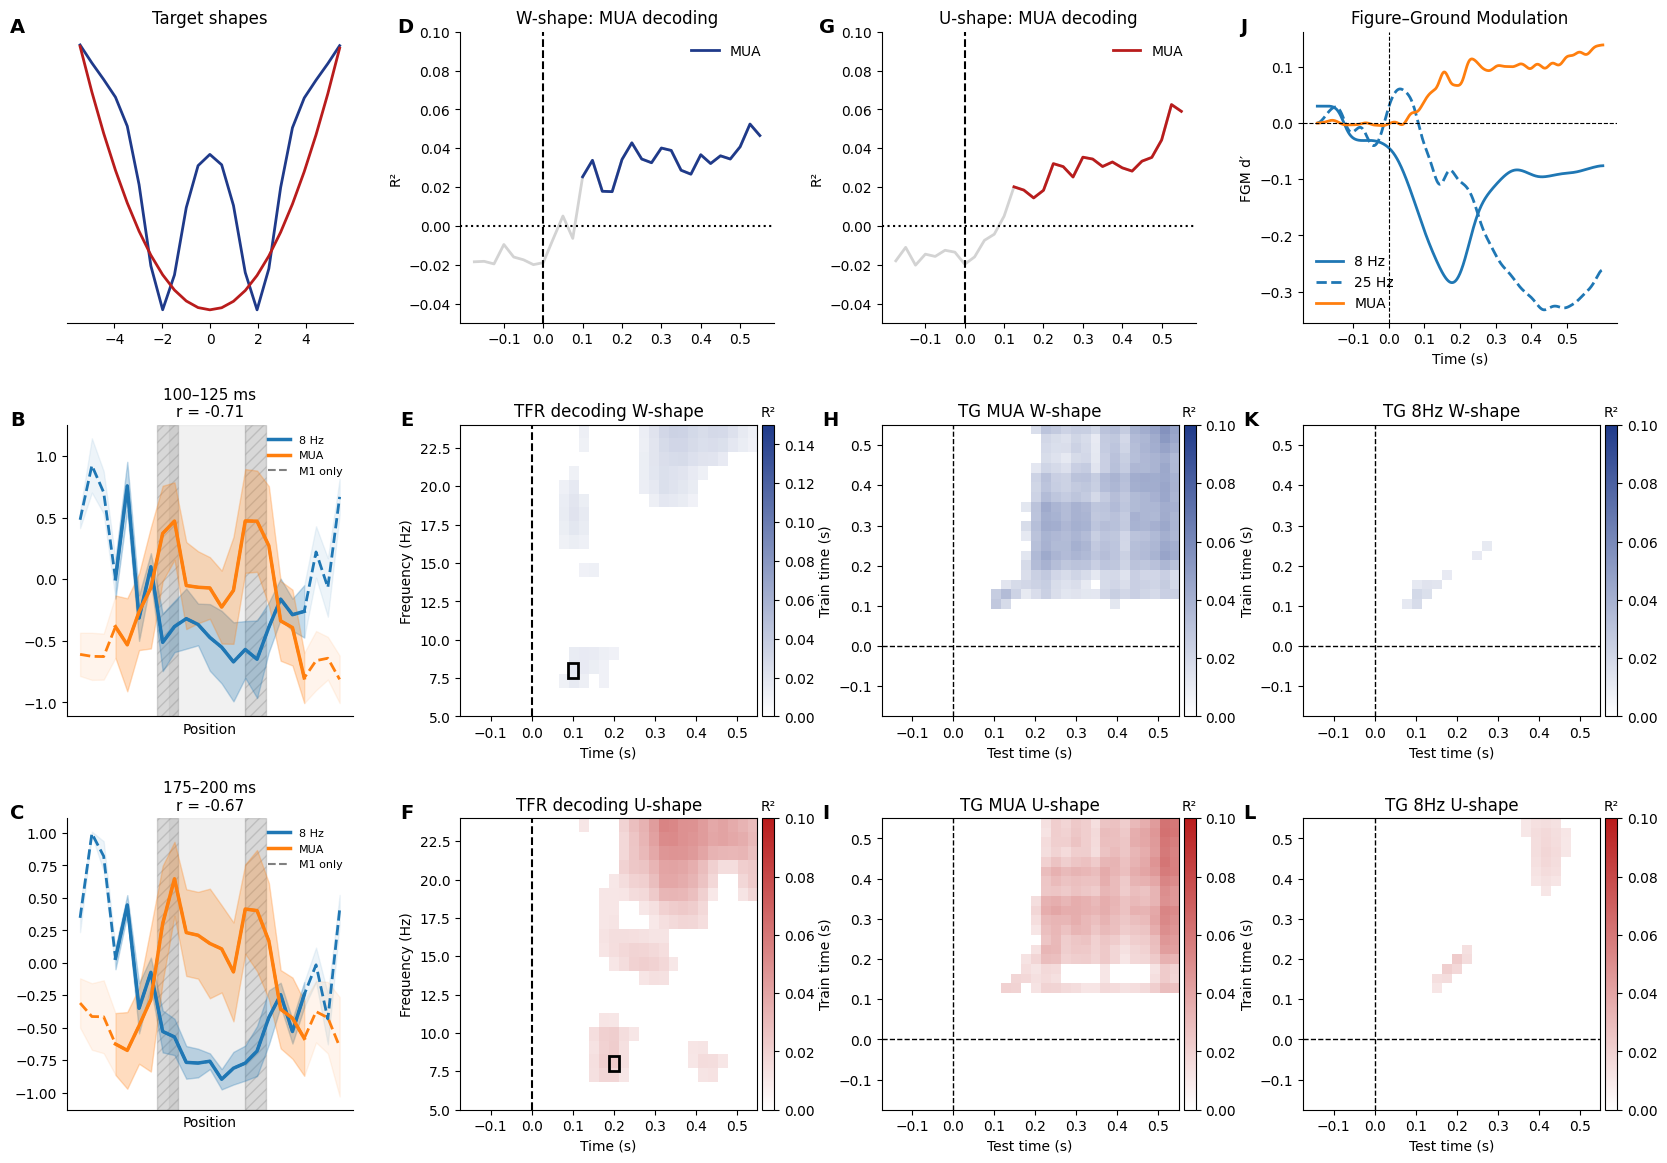

In [29]:
# =====================================================
# Main Plot Figure 1 
# =====================================================

idx_mua = -1
idx_8hz = 3

OFFSET = 3

sig_mua_W = sig_mask_W[:, idx_mua]
sig_mua_U = sig_mask_U[:, idx_mua]
sig_W_8   = sig_mask_W[:, idx_8hz]
sig_U_8   = sig_mask_U[:, idx_8hz]

cmap_W = LinearSegmentedColormap.from_list(
    "white_blue",
    ["white", color_W]
)

cmap_U = LinearSegmentedColormap.from_list(
    "white_red",
    ["white", color_U]
)

fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    3, 4,
    figure=fig,
    width_ratios=[1.0, 1.1, 1.1, 1.1],
    height_ratios=[1, 1, 1],
    wspace=0.35,
    hspace=0.35
)

positions_23 = np.arange(23)

# =====================================================
# COLUMN 1
# =====================================================

# -----------------------------------
# TARGET SHAPES
# -----------------------------------

ax_shapes = fig.add_subplot(gs[0, 0])

ax_shapes.plot(
    distances[order],
    y_W_shifted[order],
    lw=2,
    color=color_W
)

ax_shapes.plot(
    distances[order],
    y_U_shifted[order],
    lw=2,
    color=color_U
)

ax_shapes.set_title("Target shapes")

ax_shapes.spines['top'].set_visible(False)
ax_shapes.spines['right'].set_visible(False)
ax_shapes.spines['left'].set_visible(False)

ax_shapes.set_yticks([])

# -----------------------------------
# POSITION WINDOW 0
# -----------------------------------

ax_pos0 = fig.add_subplot(gs[1, 0])

plot_position_panel(
    ax_pos0,
    win_idx=0,
    title="100–125 ms"
)

ax_pos0.set_xlabel("Position")

# -----------------------------------
# POSITION WINDOW 1
# -----------------------------------

ax_pos1 = fig.add_subplot(gs[2, 0])

plot_position_panel(
    ax_pos1,
    win_idx=1,
    title="175–200 ms"
)

ax_pos1.set_xlabel("Position")

# =====================================================
# COLUMN 2
# =====================================================

# -----------------------------------
# W SHAPE LINES
# -----------------------------------

ax_w_lines = fig.add_subplot(gs[0, 1])

plot_with_significance(
    ax_w_lines,
    window_centers,
    r2_Wmean[:, idx_mua],
    sig_mua_W.astype(bool),
    color_W,
    'MUA',
    linestyle='-'
)

#plot_with_significance(
#    ax_w_lines,
#    window_centers,
#    r2_Wmean[:, idx_8hz],
#    sig_W_8.astype(bool),
#    color_W,
#    '8Hz',
#    linestyle='--'
#)

ax_w_lines.axvline(0, color='k', linestyle='--')
ax_w_lines.axhline(0, color='k', linestyle=':')

ax_w_lines.set_ylim(-0.05, 0.1)

ax_w_lines.set_title("W-shape: MUA decoding")

ax_w_lines.spines['top'].set_visible(False)
ax_w_lines.spines['right'].set_visible(False)
ax_w_lines.set_ylabel("R²")
ax_w_lines.legend(frameon=False)

# -----------------------------------
# TFR W
# -----------------------------------

ax_tfr_w = fig.add_subplot(gs[1, 1])

im1 = ax_tfr_w.imshow(
    r2_W_plot.T,
    origin="lower",
    aspect="auto",
    extent=[
        window_centers[0],
        window_centers[-1],
        freqs[0],
        freqs[-2]
    ],
    vmin=0,
    vmax=0.15,
    cmap=cmap_W
)

ax_tfr_w.axvline(0, color='k', linestyle='--')

ax_tfr_w.set_title("TFR decoding W-shape")

ax_tfr_w.set_xlabel("Time (s)")
ax_tfr_w.set_ylabel("Frequency (Hz)")

divider1 = make_axes_locatable(ax_tfr_w)

cax1 = divider1.append_axes(
    "right",
    size="4%",
    pad=0.05
)

#fig.colorbar(im1, cax=cax1)

cbar1 = fig.colorbar(im1, cax=cax1)
cbar1.ax.set_title("R²", fontsize=10)

idx_t = np.argmin(np.abs(window_centers - 0.1))
idx_f = 3  # 8Hz

t_center = window_centers[idx_t]
f_center = freqs[idx_f]

# ширина одного "пикселя" в единицах осей
dt = window_centers[1] - window_centers[0]
df = freqs[1] - freqs[0]

rect = plt.Rectangle(
    (t_center - dt/2, f_center - df/2),
    dt, df,
    linewidth=2, edgecolor='black', facecolor='none'
)
ax_tfr_w.add_patch(rect)
# -----------------------------------
# TFR U
# -----------------------------------

ax_tfr_u = fig.add_subplot(gs[2, 1])

im2 = ax_tfr_u.imshow(
    r2_U_plot.T,
    origin="lower",
    aspect="auto",
    extent=[
        window_centers[0],
        window_centers[-1],
        freqs[0],
        freqs[-2]
    ],
    vmin=0,
    vmax=0.10,
    cmap=cmap_U
)

ax_tfr_u.axvline(0, color='k', linestyle='--')

ax_tfr_u.set_title("TFR decoding U-shape")

ax_tfr_u.set_xlabel("Time (s)")
ax_tfr_u.set_ylabel("Frequency (Hz)")

divider2 = make_axes_locatable(ax_tfr_u)

cax2 = divider2.append_axes(
    "right",
    size="4%",
    pad=0.05
)

#fig.colorbar(im1, cax=cax1)

cbar2 = fig.colorbar(im2, cax=cax2)
cbar2.ax.set_title("R²", fontsize=10)

idx_t = np.argmin(np.abs(window_centers - 0.2))
idx_f = 3  # 8Hz

t_center = window_centers[idx_t]
f_center = freqs[idx_f]

# ширина одного "пикселя" в единицах осей
dt = window_centers[1] - window_centers[0]
df = freqs[1] - freqs[0]

rect = plt.Rectangle(
    (t_center - dt/2, f_center - df/2),
    dt, df,
    linewidth=2, edgecolor='black', facecolor='none'
)
ax_tfr_u.add_patch(rect)

# =====================================================
# COLUMN 3
# =====================================================

# -----------------------------------
# U SHAPE LINES
# -----------------------------------

ax_u_lines = fig.add_subplot(gs[0, 2])

plot_with_significance(
    ax_u_lines,
    window_centers,
    r2_Umean[:, idx_mua],
    sig_mua_U.astype(bool),
    color_U,
    'MUA',
    linestyle='-'
)

#plot_with_significance(
#    ax_u_lines,
#    window_centers,
#    r2_Umean[:, idx_8hz],
#    sig_U_8.astype(bool),
#    color_U,
#    '8Hz',
#    linestyle='--'
#)
#
ax_u_lines.axvline(0, color='k', linestyle='--')
ax_u_lines.axhline(0, color='k', linestyle=':')

ax_u_lines.set_ylim(-0.05, 0.1)

ax_u_lines.set_title("U-shape: MUA decoding")

ax_u_lines.spines['top'].set_visible(False)
ax_u_lines.spines['right'].set_visible(False)
ax_u_lines.set_ylabel("R²")
ax_u_lines.legend(frameon=False)

# -----------------------------------
# TG MUA W
# -----------------------------------

ax_tg_mua_w = fig.add_subplot(gs[1, 2])

im_tg1 = ax_tg_mua_w.imshow(
    r2_mua_W,
    origin="lower",
    aspect="auto",
    extent=[wc[0], wc[-1], wc[0], wc[-1]],
    vmin=0,
    vmax=0.10,
    cmap=cmap_W
)

ax_tg_mua_w.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_mua_w.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_mua_w.set_title("TG MUA W-shape")

ax_tg_mua_w.set_xlabel("Test time (s)")
ax_tg_mua_w.set_ylabel("Train time (s)")

divider = make_axes_locatable(ax_tg_mua_w)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

fig.colorbar(im_tg1, cax=cax)

cbar3 = fig.colorbar(im_tg1, cax=cax)
cbar3.ax.set_title("R²", fontsize=10)

# -----------------------------------
# TG MUA U
# -----------------------------------

ax_tg_mua_u = fig.add_subplot(gs[2, 2])

im_tg3 = ax_tg_mua_u.imshow(
    r2_mua_U,
    origin="lower",
    aspect="auto",
    extent=[wc[0], wc[-1], wc[0], wc[-1]],
    vmin=0,
    vmax=0.10,
    cmap=cmap_U
)

ax_tg_mua_u.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_mua_u.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_mua_u.set_title("TG MUA U-shape")

ax_tg_mua_u.set_xlabel("Test time (s)")
ax_tg_mua_u.set_ylabel("Train time (s)")

divider = make_axes_locatable(ax_tg_mua_u)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

#fig.colorbar(im_tg3, cax=cax)

cbar3 = fig.colorbar(im_tg3, cax=cax)
cbar3.ax.set_title("R²", fontsize=10)

# =====================================================
# COLUMN 4
# =====================================================

# -----------------------------------
# FGM
# -----------------------------------

ax_fgm = fig.add_subplot(gs[0, 3])

ax_fgm.plot(
    time_axis,
    fgm_dict[3],
    label="8 Hz",
    color="tab:blue",
    
    lw=2
)

ax_fgm.plot(
    time_axis,
    fgm_dict[-2],
    label="25 Hz",
    color="tab:blue",
    linestyle="--",
    lw=2
)

ax_fgm.plot(
    time_axis,
    fgm_dict[-1],
    label="MUA",
    color="tab:orange",
    lw=2
)


ax_fgm.axhline(
    0,
    color="k",
    lw=0.8,
    ls="--"
)

ax_fgm.axvline(
    0,
    color="k",
    lw=0.8,
    ls="--"
)

ax_fgm.set_xlabel("Time (s)")
ax_fgm.set_ylabel("FGM d′")

ax_fgm.set_title("Figure–Ground Modulation")

ax_fgm.legend(frameon=False)

ax_fgm.spines['top'].set_visible(False)
ax_fgm.spines['right'].set_visible(False)

# -----------------------------------
# TG 8HZ W
# -----------------------------------

ax_tg_8hz_w = fig.add_subplot(gs[1, 3])

im_tg2 = ax_tg_8hz_w.imshow(
    r2_8hz_W,
    origin="lower",
    aspect="auto",
    extent=[wc[0], wc[-1], wc[0], wc[-1]],
    vmin=0,
    vmax=0.10,
    cmap=cmap_W
)

ax_tg_8hz_w.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_8hz_w.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_8hz_w.set_title("TG 8Hz W-shape")

ax_tg_8hz_w.set_xlabel("Test time (s)")
ax_tg_8hz_w.set_ylabel("Train time (s)")

divider = make_axes_locatable(ax_tg_8hz_w)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

#fig.colorbar(im_tg2, cax=cax)

cbar3 = fig.colorbar(im_tg2, cax=cax)
cbar3.ax.set_title("R²", fontsize=10)

# -----------------------------------
# TG 8HZ U
# -----------------------------------

ax_tg_8hz_u = fig.add_subplot(gs[2, 3])

im_tg4 = ax_tg_8hz_u.imshow(
    r2_8hz_U,
    origin="lower",
    aspect="auto",
    extent=[wc[0], wc[-1], wc[0], wc[-1]],
    vmin=0,
    vmax=0.10,
    cmap=cmap_U
)

ax_tg_8hz_u.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_8hz_u.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_8hz_u.set_title("TG 8Hz U-shape")

ax_tg_8hz_u.set_xlabel("Test time (s)")
ax_tg_8hz_u.set_ylabel("Train time (s)")

divider = make_axes_locatable(ax_tg_8hz_u)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

#fig.colorbar(im_tg4, cax=cax)

cbar3 = fig.colorbar(im_tg4, cax=cax)
cbar3.ax.set_title("R²", fontsize=10)

# Column 1
add_panel_label(ax_shapes,  'A')
add_panel_label(ax_pos0,    'B')
add_panel_label(ax_pos1,    'C')

# Column 2
add_panel_label(ax_w_lines, 'D')
add_panel_label(ax_tfr_w,   'E')
add_panel_label(ax_tfr_u,   'F')

# Column 3
add_panel_label(ax_u_lines,   'G')
add_panel_label(ax_tg_mua_w,  'H')
add_panel_label(ax_tg_mua_u,  'I')

# Column 4
add_panel_label(ax_fgm,      'J')
add_panel_label(ax_tg_8hz_w, 'K')
add_panel_label(ax_tg_8hz_u, 'L')


time_axes = [
    ax_w_lines,
    ax_u_lines,
    ax_tfr_w,
    ax_tfr_u,
    ax_tg_mua_w,
    ax_tg_mua_u,
    ax_tg_8hz_w,
    ax_tg_8hz_u,
    ax_fgm
]

for ax in time_axes:
    ax.set_xticks(
        [-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5]
    )

plt.tight_layout()

plt.savefig(
     "Updated_figure1_pres.png",
     dpi=300,
     bbox_inches="tight")
plt.show()

0.8280641177347581
0.14412367476052623


C:\Users\Danila\AppData\Local\Temp\ipykernel_27072\3542941919.py:1203: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


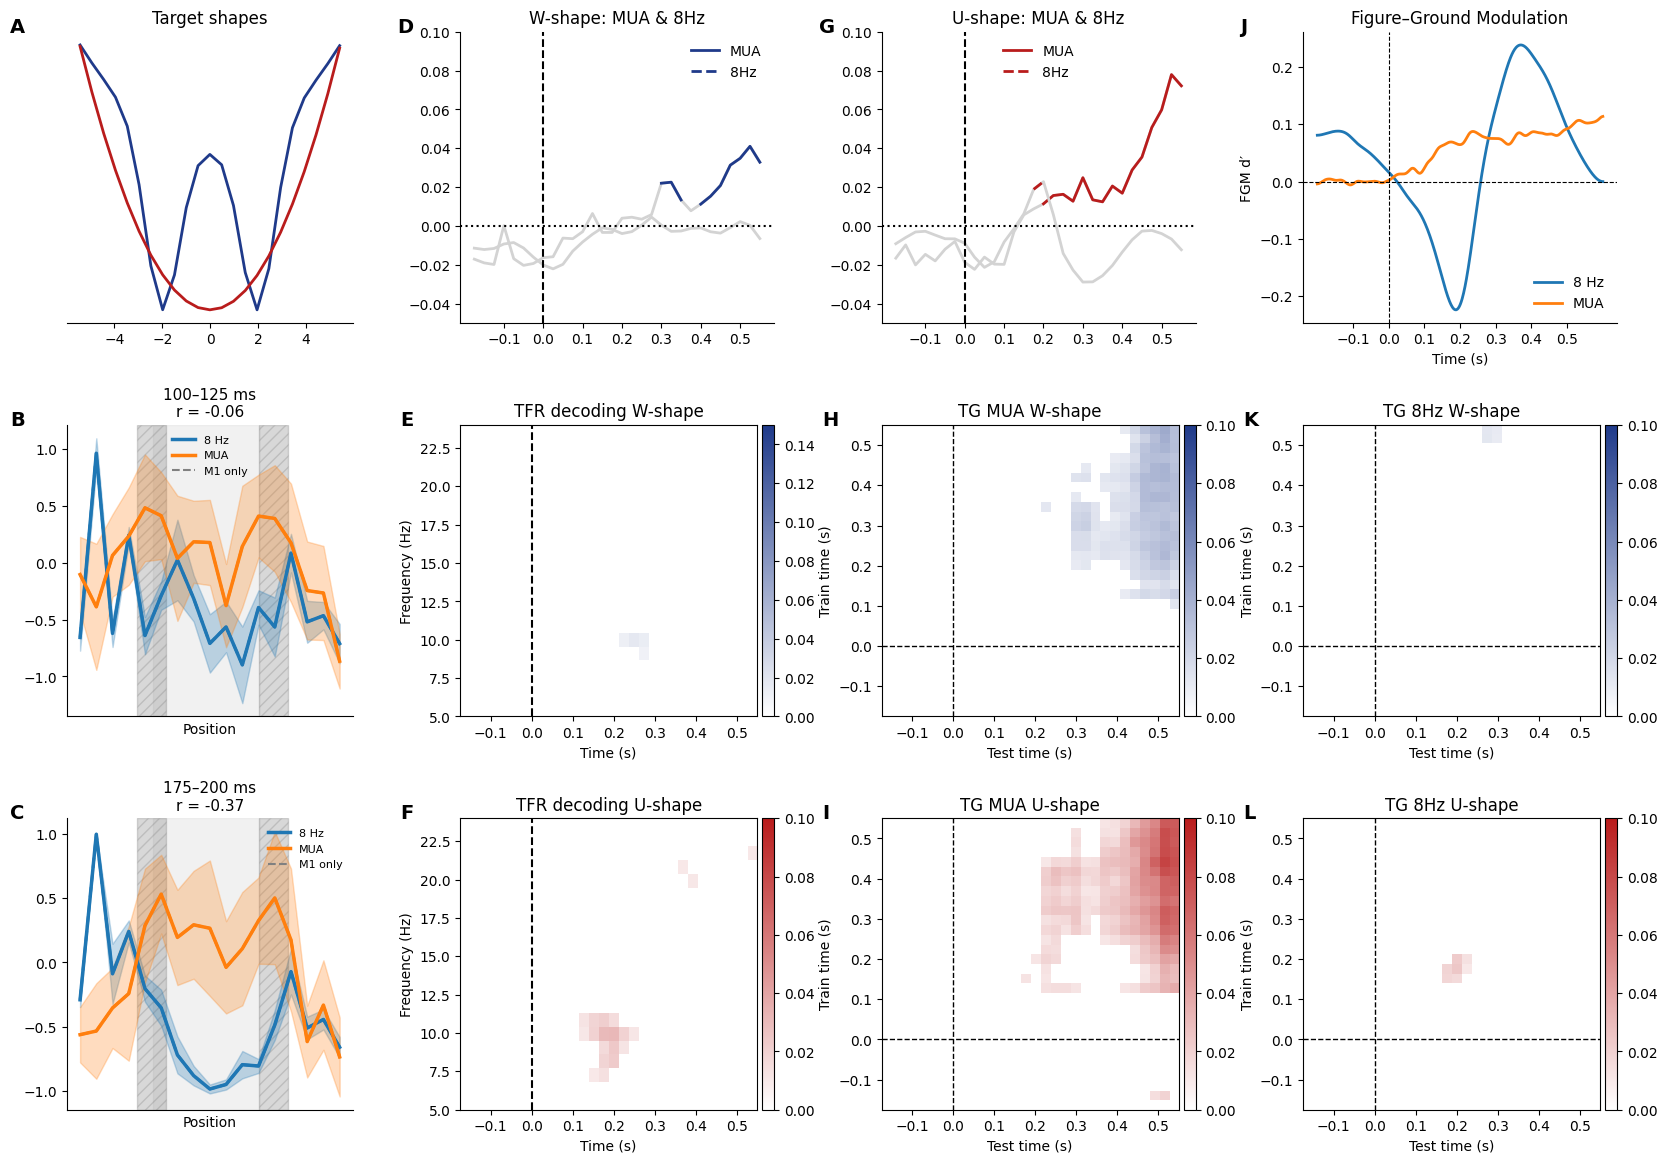

In [33]:
# =====================================================
# Supplementary individual Figures 
# =====================================================

def process_and_mask(
    path_m1_A,
    path_m1_B,
    path_m2_A,
    path_m2_B,
    key_real,
    mode="both"
):

    m1_A = np.load(path_m1_A)
    m1_B = np.load(path_m1_B)

    m2_A = np.load(path_m2_A)
    m2_B = np.load(path_m2_B)

    # -------------------------------------
    # MONKEY AVERAGES
    # -------------------------------------

    r2_m1 = 0.5 * (
        m1_A[key_real] +
        m1_B[key_real]
    )

    r2_m2 = 0.5 * (
        m2_A[key_real] +
        m2_B[key_real]
    )

    perm_m1 = 0.5 * (
        m1_A["r2_d2_perm"] +
        m1_B["r2_d2_perm"]
    )

    perm_m2 = 0.5 * (
        m2_A["r2_d2_perm"] +
        m2_B["r2_d2_perm"]
    )

    # -------------------------------------
    # MODE
    # -------------------------------------

    r2 = select_mode_data(
        r2_m1,
        r2_m2,
        mode
    )

    perm = select_mode_data(
        perm_m1,
        perm_m2,
        mode
    )

    window_centers = m1_A["window_centers"]

    perm = np.transpose(
        perm,
        (1, 2, 0)
    )

    # -------------------------------------
    # PVALUES
    # -------------------------------------

    p_vals = np.mean(
        perm >= r2[..., None],
        axis=-1
    )

    reject, _ = fdrcorrection(
        p_vals.ravel(),
        alpha=alpha_fdr
    )

    sig_mask = reject.reshape(
        p_vals.shape
    )

    sig_mask &= (r2 >= r2_min)

    r2_plot = r2.copy()

    r2_plot[~sig_mask] = np.nan

    return r2_plot, window_centers

def plot_with_significance(
    ax,
    x,
    y,
    sig_mask,
    color,
    label=None,
    linestyle='-'
):

    ax.plot(
        x,
        y,
        color='lightgray',
        lw=2,
        linestyle='-'
    )

    ax.plot(
        x,
        np.where(sig_mask, y, np.nan),
        color=color,
        lw=2,
        linestyle=linestyle,
        label=label
    )

def plot_position_panel(ax, win_idx, title):

    mean_8hz_m1 = results["mean_8hz"][win_idx]
    mean_mua_m1 = results["mean_mua"][win_idx]

    std_8hz_m1 = results["std_8hz"][win_idx]
    std_mua_m1 = results["std_mua"][win_idx]

    mean_8hz_m2 = align_to_23(
        resultsM2["mean_8hz"][win_idx],
        OFFSET
    )

    mean_mua_m2 = align_to_23(
        resultsM2["mean_mua"][win_idx],
        OFFSET
    )

    std_8hz_m2 = align_to_23(
        resultsM2["std_8hz"][win_idx],
        OFFSET
    )

    std_mua_m2 = align_to_23(
        resultsM2["std_mua"][win_idx],
        OFFSET
    )

    # -------------------------------------
    # MODE SELECTION
    # -------------------------------------

    mean_8hz = select_position_data(
        mean_8hz_m1,
        mean_8hz_m2,
        MODE
    )

    mean_mua = select_position_data(
        mean_mua_m1,
        mean_mua_m2,
        MODE
    )

    std_8hz = select_position_data(
        std_8hz_m1,
        std_8hz_m2,
        MODE
    )

    std_mua = select_position_data(
        std_mua_m1,
        std_mua_m2,
        MODE
    )

    # -------------------------------------
    # MASK
    # -------------------------------------

    if MODE == "both":

        both_mask = (
            ~np.isnan(mean_8hz_m1) &
            ~np.isnan(mean_8hz_m2)
        )

    else:

        both_mask = np.ones(
            len(mean_8hz),
            dtype=bool
        )

    # -------------------------------------
    # CORRELATION
    # -------------------------------------

    valid = (
        ~np.isnan(mean_8hz) &
        ~np.isnan(mean_mua)
    )

    r, p = pearsonr(
        mean_8hz[valid],
        mean_mua[valid]
    )
    print(p)
    # -------------------------------------
    # BACKGROUND
    # -------------------------------------

    ax.axvspan(
        7.5,
        14,
        color="lightgray",
        alpha=0.3
    )

    for pos in [7, 14.5]:

        ax.axvspan(
            pos - 0.5,
            pos + 1.3,
            color="gray",
            alpha=0.3,
            hatch="///"
        )

    # -------------------------------------
    # DRAW FUNCTION
    # -------------------------------------

    def draw_series(values, std, color, label):

        ax.plot(
            positions_23,
            values,
            color=color,
            lw=2,
            ls="--"
        )

        ax.fill_between(
            positions_23,
            values - std,
            values + std,
            color=color,
            alpha=0.08
        )

        vals_solid = np.where(
            both_mask,
            values,
            np.nan
        )

        ax.plot(
            positions_23,
            vals_solid,
            color=color,
            lw=2.5,
            label=label
        )

        ax.fill_between(
            positions_23,
            vals_solid - std,
            vals_solid + std,
            color=color,
            alpha=0.20,
            where=~np.isnan(vals_solid)
        )

    draw_series(
        mean_8hz,
        std_8hz,
        "tab:blue",
        "8 Hz"
    )

    draw_series(
        mean_mua,
        std_mua,
        "tab:orange",
        "MUA"
    )

    ax.plot(
        [],
        [],
        color="gray",
        lw=1.5,
        ls="--",
        label="M1 only"
    )

    ax.set_title(
        f"{title}\nr = {r:.2f}",
        fontsize=11
    )

    ax.set_xticks([])

    ax.tick_params(
        axis='x',
        length=0
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.legend(
        fontsize=8,
        frameon=False
    )

# =====================================================
# CONFIG
# =====================================================

MODE = "M2"
# MODE = "M2"
# MODE = "both"

alpha_fdr = 0.05
r2_min = 0.01

freqs = np.arange(5, 26)

color_W = "#1F3A8A"
color_U = "#B91C1C"

idx_mua = -1
idx_8hz = 3

OFFSET = 3


# =====================================================
# LOAD POSITION / FGM DATA
# =====================================================
data = np.load("Danila/fgm_position_data_long_forsep.npz", allow_pickle=True)


fgm_dict = data["fgm_both"].item()
FGM_m1 = data["FGM"]
FGM_m2 = data["FGMM2"] 

fgm = {
    "both": data["fgm_both"].item(),
    "m1": data["FGM"],
    "m2": data["FGMM2"],
}

data = np.load(
    "Danila/fgm_position_data.npz",
    allow_pickle=True
)

time_axis = data["time_axis"]

positions_23 = data["positions_23"]

OFFSET = 3

#fgm_both = data["fgm_both"] 
#fgm_dict = data["fgm_both"].item()
#fgm_dict = fgm_both.item()
#fgm_both_edge = data["fgm_both_edge"]

# =====================================================
# REBUILD POSITION RESULTS
# =====================================================

results = {

    "mean_8hz": [
        data["win0_mean_8hz_m1"],
        data["win1_mean_8hz_m1"],
    ],

    "mean_mua": [
        data["win0_mean_mua_m1"],
        data["win1_mean_mua_m1"],
    ],

    "std_8hz": [
        data["win0_std_8hz_m1"],
        data["win1_std_8hz_m1"],
    ],

    "std_mua": [
        data["win0_std_mua_m1"],
        data["win1_std_mua_m1"],
    ],
}


resultsM2 = {

    "mean_8hz": [
        data["win0_mean_8hz_m2"],
        data["win1_mean_8hz_m2"],
    ],

    "mean_mua": [
        data["win0_mean_mua_m2"],
        data["win1_mean_mua_m2"],
    ],

    "std_8hz": [
        data["win0_std_8hz_m2"],
        data["win1_std_8hz_m2"],
    ],

    "std_mua": [
        data["win0_std_mua_m2"],
        data["win1_std_mua_m2"],
    ],
}


# =====================================================
# DATASETS
# =====================================================

if MODE == "M1":

    datasets_list = [datasets_monkey1]

elif MODE == "M2":

    datasets_list = [datasets_monkey2]

elif MODE == "both":

    datasets_list = [
        datasets_monkey1,
        datasets_monkey2
    ]


# =====================================================
# TARGET SHAPES
# =====================================================

distances = np.array([
     -5.43721027321671, -4.94374858879742,
     -4.45028690437813, -3.95682521995884,
     -3.46336353553955, -2.96990185112026,
     -2.47644016670097, -1.98297848228168,
     -1.48951679786239, -0.996055113443101,
     -0.50259342902381, -0.00913174460452,
      0.48432993981477,  0.977791624234061,
      1.47125330865335,  1.96471499307264,
      2.45817667749193,  2.95163836191122,
      3.44510004633051,  3.9385617307498,
      4.43202341516909,  4.92548509958838,
      5.41894678400767
])

order = np.argsort(distances)

sigma_side = 0.7
beta = 0.02

y_W_flat = (
    -np.exp(-((distances + 2)**2) / (2 * sigma_side**2))
    -np.exp(-((distances - 2)**2) / (2 * sigma_side**2))
    + beta * (distances ** 2)
)

y_W_flat = (
    y_W_flat - y_W_flat.mean()
) / y_W_flat.std()

y_U = distances**2

y_U = (
    y_U - y_U.mean()
) / y_U.std()

min_common = min(
    y_U.min(),
    y_W_flat.min()
)

y_U_shifted = (
    y_U - y_U.min() + min_common
)

y_W_shifted = (
    y_W_flat - y_W_flat.min() + min_common
)


# =====================================================
# TFR DECODING
# =====================================================

r2_W_plot, r2_Wmean, sig_mask_W, window_centers = \
    plot_common_tf_for_regressor(
        area='V1',
        datasets_list=datasets_list,
        r2_key='r2_W_flat',
        r2_perm_key='r2_perm_W_flat',
        title_suffix='W-shape',
        freqs=freqs,
)

r2_U_plot, r2_Umean, sig_mask_U, _ = \
    plot_common_tf_for_regressor(
        area='V1',
        datasets_list=datasets_list,
        r2_key='r2_d2',
        r2_perm_key='r2_perm_d2',
        title_suffix='U-shape',
        freqs=freqs,
)


# =====================================================
# SIGNIFICANCE MASKS
# =====================================================

sig_mua_W = sig_mask_W[:, idx_mua]
sig_mua_U = sig_mask_U[:, idx_mua]

sig_W_8 = sig_mask_W[:, idx_8hz]
sig_U_8 = sig_mask_U[:, idx_8hz]

# =====================================================
# TG PATHS
# =====================================================

path_m1_A_mua = r"Danila\M1V1tg_loso_results\mix_A_tg_results.npz"
path_m1_B_mua = r"Danila\M1V1tg_loso_results\mix_B_tg_results.npz"

path_m2_A_mua = r"Danila/Downloads/M2V1tg_loso_results_muanew/A_tg_results.npz"
path_m2_B_mua = r"Danila/Downloads/M2V1tg_loso_results_muanew/B_tg_results.npz"

path_m1_A_8hz = r"Danila\M1V1tg_loso_results_8hz\mix_A_tg_results.npz"
path_m1_B_8hz = r"Danila\M1V1tg_loso_results_8hz\mix_B_tg_results.npz"

path_m2_A_8hz = r"Danila\Downloads/M2V1tg_loso_results_8hz\A_tg_results.npz"
path_m2_B_8hz = r"Danila\Downloads/M2V1tg_loso_results_8hz\B_tg_results.npz"


# =====================================================
# LOAD TG
# =====================================================

r2_mua_W, wc = process_and_mask(
    path_m1_A_mua,
    path_m1_B_mua,
    path_m2_A_mua,
    path_m2_B_mua,
    "r2_W_mean",
    mode=MODE
)

r2_8hz_W, _ = process_and_mask(
    path_m1_A_8hz,
    path_m1_B_8hz,
    path_m2_A_8hz,
    path_m2_B_8hz,
    "r2_W_mean",
    mode=MODE
)

r2_mua_U, _ = process_and_mask(
    path_m1_A_mua,
    path_m1_B_mua,
    path_m2_A_mua,
    path_m2_B_mua,
    "r2_d2_mean",
    mode=MODE
)

r2_8hz_U, _ = process_and_mask(
    path_m1_A_8hz,
    path_m1_B_8hz,
    path_m2_A_8hz,
    path_m2_B_8hz,
    "r2_d2_mean",
    mode=MODE
)


# =====================================================
# COLORMAPS
# =====================================================

cmap_W = LinearSegmentedColormap.from_list(
    "white_blue",
    ["white", color_W]
)

cmap_U = LinearSegmentedColormap.from_list(
    "white_red",
    ["white", color_U]
)

# =====================================================
# FIGURE
# =====================================================

fig = plt.figure(figsize=(20, 14))

gs = gridspec.GridSpec(
    3,
    4,
    figure=fig,
    width_ratios=[1.0, 1.1, 1.1, 1.1],
    height_ratios=[1, 1, 1],
    wspace=0.35,
    hspace=0.35
)

# =====================================================
# COLUMN 1
# =====================================================

ax_shapes = fig.add_subplot(gs[0, 0])

ax_shapes.plot(
    distances[order],
    y_W_shifted[order],
    lw=2,
    color=color_W
)

ax_shapes.plot(
    distances[order],
    y_U_shifted[order],
    lw=2,
    color=color_U
)

ax_shapes.set_title("Target shapes")

ax_shapes.spines['top'].set_visible(False)
ax_shapes.spines['right'].set_visible(False)
ax_shapes.spines['left'].set_visible(False)

ax_shapes.set_yticks([])


ax_pos0 = fig.add_subplot(gs[1, 0])

plot_position_panel(
    ax_pos0,
    win_idx=0,
    title="100–125 ms"
)

ax_pos0.set_xlabel("Position")


ax_pos1 = fig.add_subplot(gs[2, 0])

plot_position_panel(
    ax_pos1,
    win_idx=1,
    title="175–200 ms"
)

ax_pos1.set_xlabel("Position")


# =====================================================
# COLUMN 2
# =====================================================

ax_w_lines = fig.add_subplot(gs[0, 1])

plot_with_significance(
    ax_w_lines,
    window_centers,
    r2_Wmean[:, idx_mua],
    sig_mua_W.astype(bool),
    color_W,
    'MUA',
    linestyle='-'
)

plot_with_significance(
    ax_w_lines,
    window_centers,
    r2_Wmean[:, idx_8hz],
    sig_W_8.astype(bool),
    color_W,
    '8Hz',
    linestyle='--'
)

ax_w_lines.axvline(0, color='k', linestyle='--')
ax_w_lines.axhline(0, color='k', linestyle=':')

ax_w_lines.set_ylim(-0.05, 0.1)

ax_w_lines.set_title("W-shape: MUA & 8Hz")

ax_w_lines.spines['top'].set_visible(False)
ax_w_lines.spines['right'].set_visible(False)

ax_w_lines.legend(frameon=False)


# =====================================================
# TFR W
# =====================================================

ax_tfr_w = fig.add_subplot(gs[1, 1])

im1 = ax_tfr_w.imshow(
    r2_W_plot.T,
    origin="lower",
    aspect="auto",
    extent=[
        window_centers[0],
        window_centers[-1],
        freqs[0],
        freqs[-2]
    ],
    vmin=0,
    vmax=0.15,
    cmap=cmap_W
)

ax_tfr_w.axvline(0, color='k', linestyle='--')

ax_tfr_w.set_title("TFR decoding W-shape")

ax_tfr_w.set_xlabel("Time (s)")
ax_tfr_w.set_ylabel("Frequency (Hz)")

divider1 = make_axes_locatable(ax_tfr_w)

cax1 = divider1.append_axes(
    "right",
    size="4%",
    pad=0.05
)

fig.colorbar(im1, cax=cax1)


# =====================================================
# TFR U
# =====================================================

ax_tfr_u = fig.add_subplot(gs[2, 1])

im2 = ax_tfr_u.imshow(
    r2_U_plot.T,
    origin="lower",
    aspect="auto",
    extent=[
        window_centers[0],
        window_centers[-1],
        freqs[0],
        freqs[-2]
    ],
    vmin=0,
    vmax=0.10,
    cmap=cmap_U
)

ax_tfr_u.axvline(0, color='k', linestyle='--')

ax_tfr_u.set_title("TFR decoding U-shape")

ax_tfr_u.set_xlabel("Time (s)")
ax_tfr_u.set_ylabel("Frequency (Hz)")

divider2 = make_axes_locatable(ax_tfr_u)

cax2 = divider2.append_axes(
    "right",
    size="4%",
    pad=0.05
)

fig.colorbar(im2, cax=cax2)


# =====================================================
# COLUMN 3
# =====================================================

ax_u_lines = fig.add_subplot(gs[0, 2])

plot_with_significance(
    ax_u_lines,
    window_centers,
    r2_Umean[:, idx_mua],
    sig_mua_U.astype(bool),
    color_U,
    'MUA',
    linestyle='-'
)

plot_with_significance(
    ax_u_lines,
    window_centers,
    r2_Umean[:, idx_8hz],
    sig_U_8.astype(bool),
    color_U,
    '8Hz',
    linestyle='--'
)

ax_u_lines.axvline(0, color='k', linestyle='--')
ax_u_lines.axhline(0, color='k', linestyle=':')

ax_u_lines.set_ylim(-0.05, 0.1)

ax_u_lines.set_title("U-shape: MUA & 8Hz")

ax_u_lines.spines['top'].set_visible(False)
ax_u_lines.spines['right'].set_visible(False)

ax_u_lines.legend(frameon=False)


# =====================================================
# TG MUA W
# =====================================================

ax_tg_mua_w = fig.add_subplot(gs[1, 2])

im_tg1 = ax_tg_mua_w.imshow(
    r2_mua_W,
    origin="lower",
    aspect="auto",
    extent=[wc[0], wc[-1], wc[0], wc[-1]],
    vmin=0,
    vmax=0.10,
    cmap=cmap_W
)

ax_tg_mua_w.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_mua_w.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_mua_w.set_title("TG MUA W-shape")

ax_tg_mua_w.set_xlabel("Test time (s)")
ax_tg_mua_w.set_ylabel("Train time (s)")

divider = make_axes_locatable(ax_tg_mua_w)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

fig.colorbar(im_tg1, cax=cax)


# =====================================================
# TG MUA U
# =====================================================

ax_tg_mua_u = fig.add_subplot(gs[2, 2])

im_tg3 = ax_tg_mua_u.imshow(
    r2_mua_U,
    origin="lower",
    aspect="auto",
    extent=[wc[0], wc[-1], wc[0], wc[-1]],
    vmin=0,
    vmax=0.10,
    cmap=cmap_U
)

ax_tg_mua_u.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_mua_u.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_mua_u.set_title("TG MUA U-shape")

ax_tg_mua_u.set_xlabel("Test time (s)")
ax_tg_mua_u.set_ylabel("Train time (s)")

divider = make_axes_locatable(ax_tg_mua_u)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

fig.colorbar(im_tg3, cax=cax)


# =====================================================
# COLUMN 4
# =====================================================

ax_fgm = fig.add_subplot(gs[0, 3])

ax_fgm.plot(
    time_axis,
    fgm["m2"].item()[3],
    label="8 Hz",
    color="tab:blue",
    lw=2
)

ax_fgm.plot(
    time_axis,
    fgm["m2"].item()[-1],
    label="MUA",
    color="tab:orange",
    lw=2
)

ax_fgm.axhline(
    0,
    color="k",
    lw=0.8,
    ls="--"
)

ax_fgm.axvline(
    0,
    color="k",
    lw=0.8,
    ls="--"
)

ax_fgm.set_xlabel("Time (s)")
ax_fgm.set_ylabel("FGM d′")

ax_fgm.set_title("Figure–Ground Modulation")

ax_fgm.legend(frameon=False)

ax_fgm.spines['top'].set_visible(False)
ax_fgm.spines['right'].set_visible(False)


# =====================================================
# TG 8HZ W
# =====================================================

ax_tg_8hz_w = fig.add_subplot(gs[1, 3])

im_tg2 = ax_tg_8hz_w.imshow(
    r2_8hz_W,
    origin="lower",
    aspect="auto",
    extent=[wc[0], wc[-1], wc[0], wc[-1]],
    vmin=0,
    vmax=0.10,
    cmap=cmap_W
)

ax_tg_8hz_w.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_8hz_w.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_8hz_w.set_title("TG 8Hz W-shape")

ax_tg_8hz_w.set_xlabel("Test time (s)")
ax_tg_8hz_w.set_ylabel("Train time (s)")

divider = make_axes_locatable(ax_tg_8hz_w)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

fig.colorbar(im_tg2, cax=cax)


# =====================================================
# TG 8HZ U
# =====================================================

ax_tg_8hz_u = fig.add_subplot(gs[2, 3])

im_tg4 = ax_tg_8hz_u.imshow(
    r2_8hz_U,
    origin="lower",
    aspect="auto",
    extent=[wc[0], wc[-1], wc[0], wc[-1]],
    vmin=0,
    vmax=0.10,
    cmap=cmap_U
)

ax_tg_8hz_u.axvline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_8hz_u.axhline(
    0,
    color='k',
    linestyle='--',
    linewidth=1
)

ax_tg_8hz_u.set_title("TG 8Hz U-shape")

ax_tg_8hz_u.set_xlabel("Test time (s)")
ax_tg_8hz_u.set_ylabel("Train time (s)")

divider = make_axes_locatable(ax_tg_8hz_u)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.05
)

fig.colorbar(im_tg4, cax=cax)


# =====================================================
# LABELS
# =====================================================

add_panel_label(ax_shapes, 'A')
add_panel_label(ax_pos0, 'B')
add_panel_label(ax_pos1, 'C')

add_panel_label(ax_w_lines, 'D')
add_panel_label(ax_tfr_w, 'E')
add_panel_label(ax_tfr_u, 'F')

add_panel_label(ax_u_lines, 'G')
add_panel_label(ax_tg_mua_w, 'H')
add_panel_label(ax_tg_mua_u, 'I')

add_panel_label(ax_fgm, 'J')
add_panel_label(ax_tg_8hz_w, 'K')
add_panel_label(ax_tg_8hz_u, 'L')


# =====================================================
# COMMON X TICKS
# =====================================================

time_axes = [
    ax_w_lines,
    ax_u_lines,
    ax_tfr_w,
    ax_tfr_u,
    ax_tg_mua_w,
    ax_tg_mua_u,
    ax_tg_8hz_w,
    ax_tg_8hz_u,
    ax_fgm
]

for ax in time_axes:

    ax.set_xticks([
        -0.1,
        0,
        0.1,
        0.2,
        0.3,
        0.4,
        0.5
    ])


# =====================================================
# SAVE
# =====================================================

plt.tight_layout()

plt.savefig(
    f"Updated_figure1_{MODE}.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()